### Working example of GM energy from moments. 

In [1]:
import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc
import numpy as np
from pyscf.fci import direct_spin1
import math
import matplotlib.pyplot as plt


In [2]:
mol = gto.Mole(
    atom = 'H 0 0 0; H 0 0 1.4', 
    basis = 'sto-3g', # minimal basis set
    spin = 0 # singlet state
)

# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel() 

one_ao = mol.intor_symmetric('int1e_kin') + mol.intor_symmetric('int1e_nuc')
two_ao = mol.intor('int2e_sph')

one_mo = np.einsum('pi,pq,qj->ij', mf.mo_coeff, one_ao, mf.mo_coeff)
two_mo = ao2mo.incore.full(two_ao, mf.mo_coeff)
two_mo = np.swapaxes(two_mo, 1, 3)

# qubit Hamiltonian
h1 = one_particle(one_mo)
h2 = two_particle(two_mo)

qubit_hamiltonian = observable(h1, h2, mapping='jordan_wigner')

print(qubit_hamiltonian)

converged SCF energy = -0.941480654707798
-0.8517840380466506 * I(0) + 0.10053557435398464 * Z(0) + 0.10053557435398464 * Z(1) + 0.1412046815136504 * (Z(0) @ Z(1)) + 0.05575552226867869 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.05575552226867869 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.05575552226867869 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.05575552226867869 * (X(0) @ Y(1) @ Y(2) @ X(3)) + -0.0490323644148602 * Z(2) + 0.08678749878785737 * (Z(0) @ Z(2)) + -0.0490323644148602 * Z(3) + 0.08678749878785737 * (Z(1) @ Z(3)) + 0.14254302105653605 * (Z(0) @ Z(3)) + 0.14254302105653605 * (Z(1) @ Z(2)) + 0.14891189696596427 * (Z(2) @ Z(3))


Initialize <pyscf.gto.mole.Mole object at 0x11a62cd70> in <pyscf.scf.hf.RHF object at 0x11a9b5550>


In [4]:
def get_post_HF_energies(mf): 

    hf_energy = mf.e_tot

    # perform FCI calculation
    cisolver = fci.FCI(mf.mol, mf.mo_coeff)
    fci_energy, fci_vector = cisolver.kernel()

    # CCSD 
    ccsdsolver = cc.CCSD(mf).run()
    energy_ccsd = ccsdsolver.e_tot
    ccsd_state = qml.qchem.import_state(ccsdsolver)

    outputs = {
        'hf_energy': hf_energy,
        'fci_energy': fci_energy,
        'ccsd_energy': energy_ccsd,
        'ccsd_state': ccsd_state
    }

    return outputs

# vqe energy and state

def get_vqe_energy_and_state(mf, qubit_hamiltonian, params =None): 

    n_wires = qubit_hamiltonian.num_wires

    # GPU device 
    dev = qml.device("default.qubit", wires=n_wires)

    # build uccsd ansatz

    hf_state = qml.qchem.hf_state(mf.mol.nelectron, n_wires)

    singles,doubles = qml.qchem.excitations(mf.mol.nelectron, n_wires)

    s_wires, d_wires = qml.qchem.excitations_to_wires(singles, doubles)

    @qml.qnode(dev)
    def vqe_ansatz(theta, wires, s_wires, d_wires, hf_state):
        qml.UCCSD(theta, wires,s_wires, d_wires, hf_state)
        return qml.expval(qubit_hamiltonian)

    # define params and optimizer
    if params is None:
        params = pnp.zeros(len(singles) + len(doubles), requires_grad=True)
    else:
        params = pnp.array(params, requires_grad=True)

    opt = qml.GradientDescentOptimizer(stepsize=0.1)
    for i in range(100):
        params, energy = opt.step_and_cost(vqe_ansatz, params, wires = range(n_wires), s_wires=s_wires, d_wires=d_wires, hf_state=hf_state)
        if i % 10 == 0:
            print(f"Step {i}, Energy: {energy + gto.mole.energy_nuc(mf.mol):.6f} t")
            print(f"Params: {params}")


    outputs = {
        'vqe_energy': energy + gto.mole.energy_nuc(mf.mol),
        'vqe_params': params,
    }
    return outputs

dev_state = qml.device("default.qubit", wires=qubit_hamiltonian.num_wires)
@qml.qnode(dev_state)
def uccsd_state(theta, mf, wires):
    """
    Return UCCSD(optimised_params)|HF> as pennylane circuit.
    
    """

    # build uccsd ansatz

    hf_state = qml.qchem.hf_state(mf.mol.nelectron, len(wires))

    singles,doubles = qml.qchem.excitations(mf.mol.nelectron, len(wires))

    s_wires, d_wires = qml.qchem.excitations_to_wires(singles, doubles)

    # Prepare UCCSD(VQE) state on system register
    qml.UCCSD(theta, wires=wires, s_wires=s_wires, d_wires=d_wires, init_state=hf_state)

    return qml.state()

pyscf_outputs = get_post_HF_energies(mf)
vqe_outputs = get_vqe_energy_and_state(mf, qubit_hamiltonian)

# Print results
print("PySCF FCI Energy:", pyscf_outputs['fci_energy'])
print('PySCF CCSD Energy:', pyscf_outputs['ccsd_energy'])
print("VQE Energy:", vqe_outputs['vqe_energy'])

print(50*'-')
print('ccsd state:', pyscf_outputs['ccsd_state'])


E(CCSD) = -1.015468249381013  E_corr = -0.0739875946732145
Step 0, Energy: -0.941481 t
Params: [1.23802129e-18 8.02343760e-19 2.23022089e-02]
Step 10, Energy: -0.978884 t
Params: [6.22780331e-18 8.72864732e-18 2.10231988e-01]
Step 20, Energy: -0.997892 t
Params: [-6.95390911e-18 -4.35521748e-18  3.43808177e-01]
Step 30, Energy: -1.007144 t
Params: [-2.68727744e-18  3.31996482e-19  4.36862682e-01]
Step 40, Energy: -1.011553 t
Params: [-6.96965317e-18 -5.00194398e-18  5.01052184e-01]
Step 50, Energy: -1.013633 t
Params: [5.10982792e-18 6.37924551e-18 5.45122062e-01]
Step 60, Energy: -1.014609 t
Params: [4.84933057e-18 6.56797071e-18 5.75311248e-01]
Step 70, Energy: -1.015066 t
Params: [1.79927224e-17 2.06229625e-17 5.95970090e-01]
Step 80, Energy: -1.015280 t
Params: [2.01581779e-17 1.80781113e-17 6.10100259e-01]
Step 90, Energy: -1.015380 t
Params: [1.15443427e-17 8.77462976e-18 6.19762748e-01]
PySCF FCI Energy: -1.015468249288245
PySCF CCSD Energy: -1.0154682493810125
VQE Energy: -1.01

In [5]:
a = []
adag = []
wires = qubit_hamiltonian.wires
num_wires = len(wires)

for p in wires:
    a_p_qubit = qml.jordan_wigner(qml.FermiA(p))
    adag_p_qubit = qml.jordan_wigner(qml.FermiC(p))

    a.append(qml.matrix(a_p_qubit, wire_order=wires))
    adag.append(qml.matrix(adag_p_qubit, wire_order=wires))





In [6]:
T0_particle = np.zeros((num_wires, num_wires), dtype=complex)
T1_particle = np.zeros((num_wires, num_wires), dtype=complex)
Hmat = qubit_hamiltonian.matrix()
E0 = vqe_outputs['vqe_energy']
psi = uccsd_state(vqe_outputs['vqe_params'], mf, wires)

H_shifted = Hmat - E0 * np.eye(2**num_wires)

for p in range(num_wires):
    for q in range(num_wires):
        T0_particle[p, q] = np.vdot(
            psi,
            a[p] @ adag[q] @ psi
        )

        T1_particle[p, q] = np.vdot(
            psi,
            a[p] @ H_shifted @ adag[q] @ psi
        )

print("Particle zeroth moment:")
print(T0_particle)

print("Particle first moment:")
print(T1_particle)

Particle zeroth moment:
[[ 9.47572862e-02+0.j -2.26856546e-34+0.j -8.76086414e-18+0.j
  -1.92219498e-17+0.j]
 [-2.26856546e-34+0.j  9.47572862e-02+0.j  4.39365623e-17+0.j
  -4.29422404e-17+0.j]
 [-8.76086414e-18+0.j  4.39365623e-17+0.j  9.05242714e-01+0.j
   2.12012884e-33+0.j]
 [-1.92219498e-17+0.j -4.29422404e-17+0.j  2.12012884e-33+0.j
   9.05242714e-01+0.j]]
Particle first moment:
[[ 2.55287368e-02+0.j -6.48081084e-34+0.j  5.59874432e-18+0.j
   6.56867362e-18+0.j]
 [-6.48081084e-34+0.j  2.55287368e-02+0.j -5.78391132e-18+0.j
   4.51338417e-18+0.j]
 [ 5.59874432e-18+0.j -5.78391132e-18+0.j -4.08612510e-02+0.j
   5.71187856e-34+0.j]
 [ 6.56867362e-18+0.j  4.51338417e-18+0.j  5.71187856e-34+0.j
  -4.08612510e-02+0.j]]


In [7]:
print(one_mo)
print(one_ao)

[[-9.42141551e-01  5.55111512e-17]
 [ 5.55111512e-17 -6.58420105e-01]]
[[-0.84222891 -0.37850302]
 [-0.37850302 -0.84222891]]


In [9]:
nmo = mf.mo_coeff.shape[1]

T0_mo = np.zeros((nmo, nmo), dtype=complex)
T1_mo = np.zeros((nmo, nmo), dtype=complex)

for i in range(nmo):
    for j in range(nmo):

        ia = 2*i
        ib = 2*i + 1

        ja = 2*j
        jb = 2*j + 1

        T0_mo[i,j] = (
            T0_particle[ia,ja]
            + T0_particle[ib,jb]
        )

        T1_mo[i,j] = (
            T1_particle[ia,ja]
            + T1_particle[ib,jb]
        )


print("T0 in MO basis:")
print(T0_mo)
print("T1 in MO basis:")
print(T1_mo)


T0 in MO basis:
[[ 1.89514572e-01+0.j -5.17031045e-17+0.j]
 [-5.17031045e-17+0.j  1.81048543e+00+0.j]]
T1 in MO basis:
[[ 5.10574735e-02+0.j  1.01121285e-17+0.j]
 [ 1.01121285e-17+0.j -8.17225020e-02+0.j]]


converged SCF energy = -7.86186476980864


Initialize <pyscf.gto.mole.Mole object at 0x122d88b90> in <pyscf.scf.hf.RHF object at 0x122d88cd0>


Number of spatial MOs: 6
Number of spin orbitals/qubits: 12
Electronic qubit Hamiltonian:
-5.128074449940934 * I(0) + 1.0064988767033294 * Z(0) + 1.0064988767033294 * Z(1) + 0.4146416717146743 * (Z(0) @ Z(1)) + 0.014319294514924336 * (Y(0) @ Z(1) @ Y(2)) + 0.02792749452650557 * (Y(0) @ Y(2)) + 0.014319294514924336 * (X(0) @ Z(1) @ X(2)) + 0.02792749452650557 * (X(0) @ X(2)) + 0.014319294514924336 * (Y(1) @ Z(2) @ Y(3)) + 0.02792749452650557 * (Z(0) @ Y(1) @ Z(2) @ Y(3)) + 0.014319294514924336 * (X(1) @ Z(2) @ X(3)) + 0.02792749452650557 * (Z(0) @ X(1) @ Z(2) @ X(3)) + 0.02534772990345372 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Y(4)) + 0.03464365712081842 * (Y(0) @ Z(2) @ Z(3) @ Y(4)) + 0.02534772990345372 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ X(4)) + 0.03464365712081842 * (X(0) @ Z(2) @ Z(3) @ X(4)) + 0.02534772990345372 * (Y(1) @ Z(2) @ Z(3) @ Z(4) @ Y(5)) + 0.03464365712081842 * (Z(0) @ Y(1) @ Z(2) @ Z(3) @ Z(4) @ Y(5)) + 0.02534772990345372 * (X(1) @ Z(2) @ Z(3) @ Z(4) @ X(5)) + 0.03464365712081842

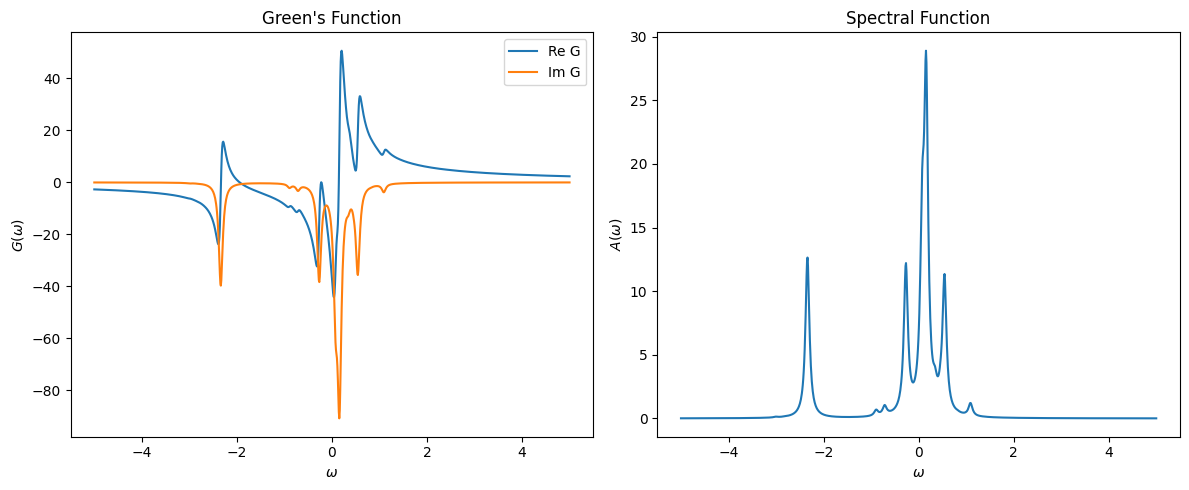

In [20]:
import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Build PySCF molecule
# ============================================================

mol = gto.Mole(
    atom = 'H 0 0 0; Li 0 0 1.6', 
    basis = 'sto-3g', # minimal basis set
    spin = 0 # singlet state
)


# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel() 

myci = fci.FCI(mf, mf.mo_coeff)

nmo = mf.mo_coeff.shape[1]
nelec = mol.nelectron
n_spin_orbitals = 2 * nmo
wires = list(range(n_spin_orbitals))

print("Number of spatial MOs:", nmo)
print("Number of spin orbitals/qubits:", n_spin_orbitals)


# ============================================================
# 2. Build molecular Hamiltonian in MO basis
# ============================================================

one_ao = mf.get_hcore()
two_ao = mol.intor("int2e_sph")

one_mo = np.einsum("pi,pq,qj->ij", mf.mo_coeff, one_ao, mf.mo_coeff)

two_mo = ao2mo.incore.full(two_ao, mf.mo_coeff)
two_mo = np.swapaxes(two_mo, 1, 3)

h1 = one_particle(one_mo)
h2 = two_particle(two_mo)

qubit_hamiltonian = observable(h1, h2, mapping="jordan_wigner")

print("Electronic qubit Hamiltonian:")
print(qubit_hamiltonian)


# ============================================================
# 3. Classical reference energies
# ============================================================

def get_post_HF_energies(mf):
    hf_energy = mf.e_tot

    cisolver = fci.FCI(mf.mol, mf.mo_coeff)
    fci_energy, fci_vector = cisolver.kernel()

    ccsdsolver = cc.CCSD(mf).run()
    ccsd_energy = ccsdsolver.e_tot

    return {
        "hf_energy": hf_energy,
        "fci_energy": fci_energy,
        "ccsd_energy": ccsd_energy,
    }


# ============================================================
# 4. VQE using UCCSD
# ============================================================

def get_vqe_energy_and_state(mf, qubit_hamiltonian, max_steps=100):
    n_wires = qubit_hamiltonian.num_wires
    wires = list(range(n_wires))

    dev = qml.device("default.qubit", wires=n_wires)

    hf_state = qml.qchem.hf_state(mf.mol.nelectron, n_wires)

    singles, doubles = qml.qchem.excitations(mf.mol.nelectron, n_wires)
    s_wires, d_wires = qml.qchem.excitations_to_wires(singles, doubles)

    @qml.qnode(dev)
    def energy_qnode(theta):
        qml.UCCSD(
            theta,
            wires=wires,
            s_wires=s_wires,
            d_wires=d_wires,
            init_state=hf_state,
        )
        return qml.expval(qubit_hamiltonian)

    @qml.qnode(dev)
    def state_qnode(theta):
        qml.UCCSD(
            theta,
            wires=wires,
            s_wires=s_wires,
            d_wires=d_wires,
            init_state=hf_state,
        )
        return qml.state()

    theta = pnp.zeros(len(singles) + len(doubles), requires_grad=True)

    opt = qml.GradientDescentOptimizer(stepsize=0.1)

    for step in range(max_steps):
        theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

        if step % 10 == 0:
            total_energy = electronic_energy + mol.energy_nuc()
            print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

    electronic_energy = energy_qnode(theta)
    total_energy = electronic_energy + mol.energy_nuc()
    psi = state_qnode(theta)

    return {
        "vqe_electronic_energy": electronic_energy,
        "vqe_total_energy": total_energy,
        "vqe_params": theta,
        "vqe_state": psi,
    }


# ============================================================
# 5. Build spin-orbital creation/annihilation matrices
# ============================================================

def build_fermionic_operators(n_spin_orbitals):
    wires = list(range(n_spin_orbitals))

    a = []
    adag = []

    for p in wires:
        a_p = qml.jordan_wigner(qml.FermiA(p))
        adag_p = qml.jordan_wigner(qml.FermiC(p))

        a.append(qml.matrix(a_p, wire_order=wires))
        adag.append(qml.matrix(adag_p, wire_order=wires))

    return a, adag


# ============================================================
# 6. MO-basis spin-summed particle, hole moments and GF
# ============================================================

def compute_mo_moments(psi, qubit_hamiltonian, nmo, nmom=1):
    """
    Compute spin-summed MO-basis particle and hole moments.

    Hole:
        T_h^(n)[i,j] =
        sum_sigma <Psi| a^dag_{i sigma}
        (E0 - H)^n
        a_{j sigma} |Psi>

    Particle:
        T_p^(n)[i,j] =
        sum_sigma <Psi| a_{i sigma}
        (H - E0)^n
        a^dag_{j sigma} |Psi>

    Returns
    -------
    dict with:
        "hole_moments"     : array of shape (nmom+1, nmo, nmo)
        "particle_moments" : array of shape (nmom+1, nmo, nmo)
    """

    n_spin_orbitals = 2 * nmo
    wires = list(range(n_spin_orbitals))

    Hmat = qml.matrix(qubit_hamiltonian, wire_order=wires)

    E0_elec = np.vdot(psi, Hmat @ psi).real

    H_particle = Hmat - E0_elec * np.eye(2**n_spin_orbitals)
    H_hole = E0_elec * np.eye(2**n_spin_orbitals) - Hmat

    a, adag = build_fermionic_operators(n_spin_orbitals)

    particle_moments = np.zeros((nmom + 1, nmo, nmo), dtype=complex)
    hole_moments = np.zeros((nmom + 1, nmo, nmo), dtype=complex)

    particle_powers = [
        np.linalg.matrix_power(H_particle, n)
        for n in range(nmom + 1)
    ]

    hole_powers = [
        np.linalg.matrix_power(H_hole, n)
        for n in range(nmom + 1)
    ]

    for n in range(nmom + 1):

        Hp_n = particle_powers[n]
        Hh_n = hole_powers[n]

        for i in range(nmo):
            for j in range(nmo):

                ia = 2 * i
                ib = 2 * i + 1

                ja = 2 * j
                jb = 2 * j + 1

                particle_moments[n, i, j] = (
                    np.vdot(
                        psi,
                        a[ia] @ Hp_n @ adag[ja] @ psi
                    )
                    +
                    np.vdot(
                        psi,
                        a[ib] @ Hp_n @ adag[jb] @ psi
                    )
                )

                hole_moments[n, i, j] = (
                    np.vdot(
                        psi,
                        adag[ia] @ Hh_n @ a[ja] @ psi
                    )
                    +
                    np.vdot(
                        psi,
                        adag[ib] @ Hh_n @ a[jb] @ psi
                    )
                )

    return {
        "E0_electronic": E0_elec,
        "hole_moments": np.real_if_close(hole_moments),
        "particle_moments": np.real_if_close(particle_moments),
    }

import numpy as np


def hermitize(A):
    return 0.5 * (A + A.conj().T)


def block_hankel_auxiliary_representation(moments, nblocks=None, threshold=1e-10):
    """
    Build a higher-order moment-conserving auxiliary Green's function.

    moments shape:
        (nmom + 1, nmo, nmo)

    If nblocks = K, this uses moments:

        M0, M1, ..., M_{2K-1}

    and builds a K*nmo dimensional auxiliary Hamiltonian.

    Returns
    -------
    eps : pole positions
    residues : list of residue matrices
    X : Dyson orbital amplitudes
    """

    moments = np.asarray(moments, dtype=complex)
    nmom_plus_1, nmo, _ = moments.shape

    if nblocks is None:
        nblocks = nmom_plus_1 // 2

    required_moments = 2 * nblocks

    if nmom_plus_1 < required_moments:
        raise ValueError(
            f"Need moments up to order {required_moments - 1} "
            f"for nblocks={nblocks}."
        )

    dim = nblocks * nmo

    # Block overlap matrix S
    # S_ab = M_{a+b}
    S = np.zeros((dim, dim), dtype=complex)

    # Block shifted moment matrix T
    # T_ab = M_{a+b+1}
    T = np.zeros((dim, dim), dtype=complex)

    for a in range(nblocks):
        for b in range(nblocks):
            S[
                a*nmo:(a+1)*nmo,
                b*nmo:(b+1)*nmo
            ] = moments[a + b]

            T[
                a*nmo:(a+1)*nmo,
                b*nmo:(b+1)*nmo
            ] = moments[a + b + 1]

    S = hermitize(S)
    T = hermitize(T)

    # Remove numerically null directions of S
    svals, U = np.linalg.eigh(S)
    keep = svals > threshold

    if np.count_nonzero(keep) == 0:
        raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

    svals = svals[keep]
    U = U[:, keep]

    S_inv_sqrt = U @ np.diag(1.0 / np.sqrt(svals))

    # Orthogonalized auxiliary Hamiltonian
    F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
    F = hermitize(F)

    eps, C = np.linalg.eigh(F)

    # Moment coupling matrix:
    # B = [M0, M1, ..., M_{K-1}]^T
    B = np.zeros((dim, nmo), dtype=complex)

    for a in range(nblocks):
        B[a*nmo:(a+1)*nmo, :] = moments[a]

    # Dyson orbital amplitudes
    X = B.conj().T @ S_inv_sqrt @ C

    residues = []

    for n in range(len(eps)):
        x = X[:, n:n+1]
        residues.append(x @ x.conj().T)

    print("moments shape:", moments.shape)
    print("nblocks:", nblocks)
    print("S dimension:", S.shape)
    print("S eigenvalues:", np.linalg.eigvalsh(S))
    print("kept:", np.count_nonzero(np.linalg.eigvalsh(S) > threshold))

    return eps, residues, X


def greens_function_from_moments(
    hole_moments,
    particle_moments,
    omega_grid,
    eta=0.05,
    nblocks=None,
):
    """
    Build G(omega) and A(omega) from higher-order hole/particle moments.

    Uses a block-Hankel moment reconstruction.
    """

    hole_moments = np.asarray(hole_moments, dtype=complex)
    particle_moments = np.asarray(particle_moments, dtype=complex)

    eps_h, residues_h, Xh = block_hankel_auxiliary_representation(
        hole_moments,
        nblocks=nblocks,
    )

    eps_p, residues_p, Xp = block_hankel_auxiliary_representation(
        particle_moments,
        nblocks=nblocks,
    )

    nmo = hole_moments.shape[1]

    omega_h = -np.abs(eps_h)
    omega_p = +np.abs(eps_p)

    G_w = np.zeros((len(omega_grid), nmo, nmo), dtype=complex)
    G_h_w = np.zeros_like(G_w)
    G_p_w = np.zeros_like(G_w)

    for iw, omega in enumerate(omega_grid):

        G_h = np.zeros((nmo, nmo), dtype=complex)
        G_p = np.zeros((nmo, nmo), dtype=complex)

        for pole, R in zip(omega_h, residues_h):
            G_h += R / (omega - pole + 1j * eta)

        for pole, R in zip(omega_p, residues_p):
            G_p += R / (omega - pole + 1j * eta)

        G_h_w[iw] = G_h
        G_p_w[iw] = G_p
        G_w[iw] = G_h + G_p

    A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
    A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
    A = A_h + A_p

    return {
        "omega": omega_grid,
        "G": G_w,
        "G_hole": G_h_w,
        "G_particle": G_p_w,
        "A": A,
        "A_hole": A_h,
        "A_particle": A_p,
        "hole_poles": eps_h,
        "particle_poles": eps_p,
        "physical_hole_poles": omega_h,
        "physical_particle_poles": omega_p,
        "hole_residues": residues_h,
        "particle_residues": residues_p,
        "hole_dyson_orbitals": Xh,
        "particle_dyson_orbitals": Xp,
    }

def galitskii_migdal_energy(one_mo, hole_moments, nuclear_repulsion_energy=0.0):
    """
    Galitskii-Migdal energy from spin-summed MO-basis hole moments.

    For RHF/spin-summed moments:

        E_elec = 1/2 [ Tr(T_h^(0) h) + Tr(T_h^(1)) ]

    """

    hole_moments = np.asarray(hole_moments, dtype=complex)

    if hole_moments.shape[0] < 2:
        raise ValueError("Need hole moments up to first order.")

    T0_hole = hole_moments[0]
    T1_hole = hole_moments[1]

    E_elec = 0.5 * (
        np.einsum("ij,ji->", T0_hole, one_mo)
        + np.trace(T1_hole)
    ).real

    return {
        "electronic": E_elec,
        "total": E_elec + nuclear_repulsion_energy,
    }
    
# ============================================================
# 7. Run everything
# ============================================================

pyscf_outputs = get_post_HF_energies(mf)
vqe_outputs = get_vqe_energy_and_state(mf, qubit_hamiltonian, max_steps=100)

moments = compute_mo_moments(
    psi=vqe_outputs["vqe_state"],
    qubit_hamiltonian=qubit_hamiltonian,
    nmo=nmo,
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = galitskii_migdal_energy(
    one_mo=one_mo,
    hole_moments=hole_moments,
    nuclear_repulsion_energy=mol.energy_nuc(),
)


print("\n" + 60 * "-")
print("Reference energies")
print("HF energy:   ", pyscf_outputs["hf_energy"])
print("FCI energy:  ", pyscf_outputs["fci_energy"])
print("CCSD energy: ", pyscf_outputs["ccsd_energy"])
print("VQE energy:  ", vqe_outputs["vqe_total_energy"])
print('Galitskii-Migdal energy from VQE state:', gm["total"])


print("\n" + 60 * "-")
omega_grid = np.linspace(-5, 5, 1000)
gf_data = greens_function_from_moments(
    hole_moments=moments["hole_moments"],
    particle_moments=moments["particle_moments"],
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,       # uses M0-M3
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Green's function
G_trace = np.trace(
    gf_data["G"],
    axis1=1,
    axis2=2
)

axes[0].plot(
    gf_data["omega"],
    G_trace.real,
    label="Re G"
)

axes[0].plot(
    gf_data["omega"],
    G_trace.imag,
    label="Im G"
)

axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

# Spectral function
axes[1].plot(
    gf_data["omega"],
    gf_data["A"]
)

axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")

plt.tight_layout()
plt.show()

In [21]:
print(gf_data["hole_dyson_orbitals"].shape)
print(gf_data["particle_dyson_orbitals"].shape)

(6, 18)
(6, 18)


In [23]:
hole_moments
[[[ 1.99990835e+00 -2.78304326e-04  4.39860999e-04 -3.61301937e-18 -1.38794663e-18 -1.28815458e-03]
  [-2.78304326e-04  1.95142599e+00  7.40395290e-02 -5.15050108e-17 -1.90962153e-17  1.10431076e-02]
  [ 4.39860999e-04  7.40395290e-02  1.25202834e-02  4.47114613e-19  1.19591703e-19 -1.74235336e-02]
  [-3.61301937e-18 -5.15050108e-17  4.47114613e-19  1.51815796e-03  6.06135368e-30 -3.69748404e-18]
  [-1.38794663e-18 -1.90962153e-17  1.19591703e-19  6.06135368e-30  1.51815796e-03 -1.31369853e-18]
  [-1.28815458e-03  1.10431076e-02 -1.74235336e-02 -3.69748404e-18 -1.31369853e-18  3.31090628e-02]]

 [[-4.69791286e+00  3.70959061e-04  8.03551605e-04  8.91501219e-18  3.57937246e-18  1.40660392e-03]
  [ 3.70959061e-04 -6.03125060e-01 -3.97303800e-03  2.29624093e-17  8.45902536e-18 -3.84792123e-02]
  [ 8.03551605e-04 -3.97303800e-03 -6.81837601e-03 -1.22623747e-18 -4.38213090e-19  1.20447707e-02]
  [ 8.91501219e-18  2.29624093e-17 -1.22623747e-18 -1.21354261e-03 -2.60914795e-29  3.23010801e-18]
  [ 3.57937246e-18  8.45902536e-18 -4.38213090e-19 -2.60914795e-29 -1.21354261e-03  1.16213010e-18]
  [ 1.40660392e-03 -3.84792123e-02  1.20447707e-02  3.23010801e-18  1.16213010e-18 -2.54350962e-02]]

 [[ 1.10832403e+01 -4.39336443e-03 -8.80475917e-03 -2.15802042e-17 -9.62248657e-18 -8.52680515e-04]
  [-4.39336443e-03  2.25277477e-01 -1.10919057e-02 -1.32389950e-17 -5.21179650e-18  3.84514482e-02]
  [-8.80475917e-03 -1.10919057e-02  5.47075409e-03  1.14259107e-18  4.41576096e-19 -9.30173457e-03]
  [-2.15802042e-17 -1.32389950e-17  1.14259107e-18  1.25621550e-03  7.15351883e-29 -2.50665625e-18]
  [-9.62248657e-18 -5.21179650e-18  4.41576096e-19  7.15351883e-29  1.25621550e-03 -9.08942841e-19]
  [-8.52680515e-04  3.84514482e-02 -9.30173457e-03 -2.50665625e-18 -9.08942841e-19  2.04289188e-02]]

 [[-2.64087983e+01  3.67863845e-02  5.77440937e-02  5.15736910e-17  2.86637545e-17 -7.48525266e-03]
  [ 3.67863845e-02 -1.15312466e-01  1.01461475e-02  9.80893021e-18  4.68304115e-18 -3.20755368e-02]
  [ 5.77440937e-02  1.01461475e-02 -9.24600852e-03 -7.46673661e-19 -4.53057546e-19  8.12630707e-03]
  [ 5.15736910e-17  9.80893021e-18 -7.46673661e-19 -2.37908794e-03 -1.73728117e-28  1.71918089e-18]
  [ 2.86637545e-17  4.68304115e-18 -4.53057546e-19 -1.73728117e-28 -2.37908794e-03  6.66366338e-19]
  [-7.48525266e-03 -3.20755368e-02  8.12630707e-03  1.71918089e-18  6.66366338e-19 -1.75039871e-02]]

 [[ 6.43911599e+01 -2.39420851e-01 -3.45838380e-01 -1.20801922e-16 -1.00437753e-16  7.13660100e-02]
  [-2.39420851e-01  9.46375139e-02  6.75994895e-03 -1.06305278e-17 -5.83082486e-18  2.05084250e-02]
  [-3.45838380e-01  6.75994895e-03  3.60866810e-02 -6.99905432e-19  8.27790939e-19 -1.08014106e-02]
  [-1.20801922e-16 -1.06305278e-17 -6.99905432e-19  8.41373797e-03  3.74352573e-28 -2.15869309e-19]
  [-1.00437753e-16 -5.83082486e-18  8.27790939e-19  3.74352573e-28  8.41373797e-03 -4.06858038e-19]
  [ 7.13660100e-02  2.05084250e-02 -1.08014106e-02 -2.15869309e-19 -4.06858038e-19  1.95176422e-02]]

 [[-1.65239527e+02  1.43574796e+00  2.01476895e+00  2.69962807e-16  4.22618270e-16 -4.92148444e-01]
  [ 1.43574796e+00 -1.72327296e-01 -9.90578190e-02  2.15295195e-17  6.57583376e-18  2.13661161e-02]
  [ 2.01476895e+00 -9.90578190e-02 -1.91940412e-01  8.53287613e-18 -3.20513459e-18  3.37226832e-02]
  [ 2.69962807e-16  2.15295195e-17  8.53287613e-18 -4.01593128e-02 -5.70077599e-28 -5.92972245e-18]
  [ 4.22618270e-16  6.57583376e-18 -3.20513459e-18 -5.70077599e-28 -4.01593128e-02 -5.77541453e-20]
  [-4.92148444e-01  2.13661161e-02  3.37226832e-02 -5.92972245e-18 -5.77541453e-20 -4.64679587e-02]]]


array([[[ 1.99991481e+00, -2.72968498e-04,  7.31499676e-04,
          1.93438197e-16, -2.37703812e-16, -9.63135087e-04],
        [-2.72968498e-04,  1.95817597e+00,  2.57561535e-02,
         -2.95941587e-16,  5.20936885e-17,  4.63808114e-03],
        [ 7.31499676e-04,  2.57561535e-02,  7.08452827e-03,
         -4.12573478e-18,  2.27491697e-19, -1.45747941e-02],
        [ 1.93438197e-16, -2.95941587e-16, -4.12573478e-18,
          1.41990222e-03, -7.44335775e-21, -1.22075858e-19],
        [-2.37703812e-16,  5.20936885e-17,  2.27491697e-19,
         -7.44335775e-21,  1.41979436e-03,  1.03995402e-18],
        [-9.63135087e-04,  4.63808114e-03, -1.45747941e-02,
         -1.22075858e-19,  1.03995402e-18,  3.19850014e-02]],

       [[-4.69858296e+00,  8.18938861e-05,  1.03533078e-05,
         -4.53462439e-16,  5.57489894e-16,  7.35414057e-04],
        [ 8.18938861e-05, -5.99693693e-01,  7.62096197e-03,
          8.79747658e-17, -1.78048658e-17, -3.54440635e-02],
        [ 1.03533078e-05,  7.6